<div style="text-align:center; font-family:Georgia, serif; background-color:#f5f5f5; padding:10px;">

  <h1 style="margin:0; padding:8px 0;">
     Optimal Policies with Dynamic Programming (Fox2016)
  </h1>


   <h3 style="margin:0; padding:6px 0;">
    RL Group Project Part 1 : Team - Reward Hunters 
  </h3>

  <h5 style="margin:0; padding:6px 0;">
    Ejisay, Mansvi, Somesh, Vasant
  </h5>

</div>


In this notebook we adapted **8×8 GridWorld** environment from Fox (2016).  
We implemented:
- Policy Evaluation
- Policy Improvement
- Value Iteration

All algorithms use the **expected costs** (without the Gaussian noise) as negative rewards.


#### 1. The GridWorld Environment

The environment is an 8×8 grid.  
- **States**: 0–63 (row‑major order). Terminal state is `[4,4]` (index 36).  
- **Actions**: 9 discrete moves (0–8): N, NE, E, SE, S, SW, W, NW, no‑op.  
- **Blocked cells**: listed in `inv_state`. Moving into them or out of bounds reverts the position and adds a large cost (1000).  
- **Stochastic drift**: After the intended move, the agent drifts with given probabilities.  
- **Cost**: Each step costs 1 (plus possible penalties). The goal is to minimise total expected cost.

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
from typing import Dict, List, Tuple

# Import the provided environment
from gridworld_env import GridWorldEnv

# Check that it works
env = GridWorldEnv()
print("Environment loaded.")

GridWorldEnv (Fox2016) Loaded...
Environment loaded.


#### 2. DP Wrapper – Providing `S`, `A`, and `transitions()`

We wrap the environment to expose the exact transition probabilities and expected rewards (cost → negative reward).  
This wrapper mimics the interface of `tools.ParkingWorld` from the original assignment.

In [13]:
class GridWorldDPWrapper:
    """
    Wrapper that provides:
      - S : list of state indices (0..63)
      - A : list of action indices (0..8)
      - transitions(s, a) : numpy array of shape (64, 2)
        Column 0 : expected reward (negative cost)
        Column 1 : probability
    """
    def __init__(self):
        self.env = GridWorldEnv()
        self.S = list(range(64))
        self.A = list(range(9))
        self.terminal_state = 36

        # Pre‑compute all transitions
        self._transitions: Dict[Tuple[int, int], np.ndarray] = {}
        self._build_transitions()

    def _build_transitions(self):
        for s in self.S:
            for a in self.A:
                self._transitions[(s, a)] = self._compute_transitions(s, a)

    def _compute_transitions(self, s: int, a: int) -> np.ndarray:
        """Return array of shape (64,2) with [reward, prob] for each next state."""
        trans = np.zeros((64, 2))

        # Terminal state is absorbing with zero reward
        if s == self.terminal_state:
            trans[s, 1] = 1.0
            return trans

        r, c = self.env.states_ind[s]

        # ---------- Intended move ----------
        deltas = {
            0: (-1,  0), 1: (-1,  1), 2: ( 0,  1), 3: ( 1,  1),
            4: ( 1,  0), 5: ( 1, -1), 6: ( 0, -1), 7: (-1, -1),
            8: ( 0,  0)
        }
        dr, dc = deltas[a]
        r_int = r + dr
        c_int = c + dc

        if self.env._is_out(r_int, c_int) or self.env._is_blocked(r_int, c_int):
            r_int, c_int = r, c
            cost_int = 1000
        else:
            cost_int = 1

        # If intended move reaches terminal, no drift occurs
        if [r_int, c_int] == [4, 4]:
            trans[self.terminal_state, 0] = -cost_int
            trans[self.terminal_state, 1] = 1.0
            return trans

        # ---------- Drift outcomes ----------
        drift_outcomes = [
            (-1, 0, 0.05), (-1, 1, 0.025), (0, 1, 0.05), (1, 1, 0.025),
            ( 1, 0, 0.05), ( 1,-1, 0.025), (0,-1, 0.05), (-1,-1, 0.025),
            ( 0, 0, 0.70)
        ]

        for dr_d, dc_d, prob_d in drift_outcomes:
            r_final = r_int + dr_d
            c_final = c_int + dc_d
            cost_drift = 1 if (dr_d, dc_d) != (0, 0) else 0

            if self.env._is_out(r_final, c_final) or self.env._is_blocked(r_final, c_final):
                r_final, c_final = r_int, c_int
                cost_drift = 0

            if [r_final, c_final] == [4, 4]:
                next_idx = self.terminal_state
                cost_drift = 1  # drift cost applies even when reaching terminal
            else:
                # Find index corresponding to (r_final, c_final)
                next_idx = None
                for idx, (rr, cc) in self.env.states_ind.items():
                    if [rr, cc] == [r_final, c_final]:
                        next_idx = idx
                        break
                # Should always be found
                if next_idx is None:
                    raise ValueError(f"State {(r_final, c_final)} not found.")

            total_cost = cost_int + cost_drift
            reward = -total_cost
            trans[next_idx, 0] += prob_d * reward
            trans[next_idx, 1] += prob_d

        return trans

    def transitions(self, s: int, a: int) -> np.ndarray:
        return self._transitions[(s, a)]


#### 3. Dynamic Programming Functions

These are the core functionswe implemented.


##### 3.1 Bellman Update for Policy Evaluation


In [15]:
def bellman_update(env: GridWorldDPWrapper, V: np.ndarray, pi: np.ndarray,
                   s: int, gamma: float) -> None:
    """
    Mutate V[s] according to the Bellman expectation equation for policy pi.
    """
    v_s = 0.0
    for a in env.A:
        prob_action = pi[s, a]
        if prob_action > 0:
            trans = env.transitions(s, a)
            probs = trans[:, 1]
            rewards = trans[:, 0]
            expected_return = np.sum(probs * (rewards + gamma * V))
            v_s += prob_action * expected_return
    V[s] = v_s

# %%
def evaluate_policy(env: GridWorldDPWrapper, V: np.ndarray, pi: np.ndarray,
                    gamma: float, theta: float) -> np.ndarray:
    """
    Iterative policy evaluation (in‑place).
    """
    delta = float('inf')
    while delta > theta:
        delta = 0.0
        for s in env.S:
            v_old = V[s]
            bellman_update(env, V, pi, s, gamma)
            delta = max(delta, abs(v_old - V[s]))
    return V

#### 3.2 Policy Improvement

In [17]:
def q_greedify_policy(env: GridWorldDPWrapper, V: np.ndarray, pi: np.ndarray,
                      s: int, gamma: float) -> None:
    """
    Make pi[s] greedy with respect to the action values Q(s,a).
    """
    q_values = np.zeros(len(env.A))
    for a in env.A:
        trans = env.transitions(s, a)
        probs = trans[:, 1]
        rewards = trans[:, 0]
        q_values[a] = np.sum(probs * (rewards + gamma * V))
    best_a = np.argmax(q_values)
    pi[s] = np.zeros(len(env.A))
    pi[s, best_a] = 1.0

In [18]:
def improve_policy(env: GridWorldDPWrapper, V: np.ndarray, pi: np.ndarray,
                   gamma: float) -> Tuple[np.ndarray, bool]:
    """
    Perform one step of policy improvement. Returns updated pi and a bool indicating stability.
    """
    policy_stable = True
    for s in env.S:
        old = pi[s].copy()
        q_greedify_policy(env, V, pi, s, gamma)
        if not np.array_equal(pi[s], old):
            policy_stable = False
    return pi, policy_stable

In [19]:
def policy_iteration(env: GridWorldDPWrapper, gamma: float, theta: float):
    """
    Full policy iteration algorithm.
    """
    V = np.zeros(len(env.S))
    pi = np.ones((len(env.S), len(env.A))) / len(env.A)
    policy_stable = False

    while not policy_stable:
        V = evaluate_policy(env, V, pi, gamma, theta)
        pi, policy_stable = improve_policy(env, V, pi, gamma)

    return V, pi

#### 3.3 Value Iteration

In [ ]:
def bellman_optimality_update(env: GridWorldDPWrapper, V: np.ndarray,
                              s: int, gamma: float) -> None:
    """
    Mutate V[s] using the Bellman optimality equation.
    """
    max_val = -float('inf')
    for a in env.A:
        trans = env.transitions(s, a)
        probs = trans[:, 1]
        rewards = trans[:, 0]
        expected_return = np.sum(probs * (rewards + gamma * V))
        if expected_return > max_val:
            max_val = expected_return
    V[s] = max_val

# %%
def value_iteration(env: GridWorldDPWrapper, gamma: float, theta: float):
    """
    Value iteration algorithm.
    """
    V = np.zeros(len(env.S))
    while True:
        delta = 0.0
        for s in env.S:
            v_old = V[s]
            bellman_optimality_update(env, V, s, gamma)
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta:
            break

    # Extract greedy policy
    pi = np.ones((len(env.S), len(env.A))) / len(env.A)
    for s in env.S:
        q_greedify_policy(env, V, pi, s, gamma)
    return V, pi

#### 4. Testing the Implementation

In [ ]:
# Create the environment wrapper
env = GridWorldDPWrapper()

# Set discount and convergence threshold
gamma = 0.9
theta = 1e-3

GridWorldEnv (Fox2016) Loaded...


#### 4.1 Policy Evaluation Example (Random Policy)

In [23]:
# Evaluate a uniform random policy
V_random = np.zeros(len(env.S))
pi_random = np.ones((len(env.S), len(env.A))) / len(env.A)

V_eval = evaluate_policy(env, V_random, pi_random, gamma, theta)

print("Value function (first 10 states) under random policy:")
print(V_eval[:10])

# %% [markdown]
# ### 4.2 Policy Iteration

# %%
V_pi, pi_pi = policy_iteration(env, gamma, theta)

print("Policy Iteration completed.")
print("Optimal value function (first 10 states):")
print(V_pi[:10])
print("\nOptimal action for each state (0..63):")
print(np.argmax(pi_pi, axis=1))

Value function (first 10 states) under random policy:
[-4184.90843483 -3329.83054615 -2732.60612159 -2607.22794932
 -2635.55286124 -2627.82988967 -2550.71480777 -2917.73738194
 -4099.73447988 -3095.86023617]
Policy Iteration completed.
Optimal value function (first 10 states):
[-3.02290659 -2.51428012 -2.51428012 -2.51428012 -2.51428012 -3.02290659
 -3.37624872 -3.54496758 -3.02290659 -2.11373006]

Optimal action for each state (0..63):
[2 3 3 4 5 6 5 5 1 3 3 4 5 7 6 6 0 3 3 4 5 0 7 7 4 2 3 3 4 5 5 7 4 1 2 2 0
 6 5 4 3 4 1 1 0 7 6 4 2 3 1 1 0 7 7 5 1 2 1 1 0 7 7 6]


#### 4.3 Value Iteration

In [26]:
V_vi, pi_vi = value_iteration(env, gamma, theta)

print("Value Iteration completed.")
print("Optimal value function (first 10 states):")
print(V_vi[:10])
print("\nOptimal action for each state (0..63):")
print(np.argmax(pi_vi, axis=1))

# %% [markdown]
# ### 4.4 Check Consistency
# Both algorithms should yield the same optimal value function and policy.

Value Iteration completed.
Optimal value function (first 10 states):
[-3.02290649 -2.51428012 -2.51428012 -2.51428012 -2.51428012 -3.02290659
 -3.37624708 -3.54494556 -3.02290658 -2.11373006]

Optimal action for each state (0..63):
[2 3 4 5 5 6 5 5 1 3 3 4 5 7 6 6 0 3 3 4 5 0 7 7 4 2 3 3 4 5 5 7 4 1 2 2 0
 6 5 4 3 4 1 1 0 7 6 4 2 3 1 1 0 7 7 5 1 2 1 1 0 7 7 6]


#### 5. Visualisation

You can visualise the value function and policy on the 8×8 grid. 

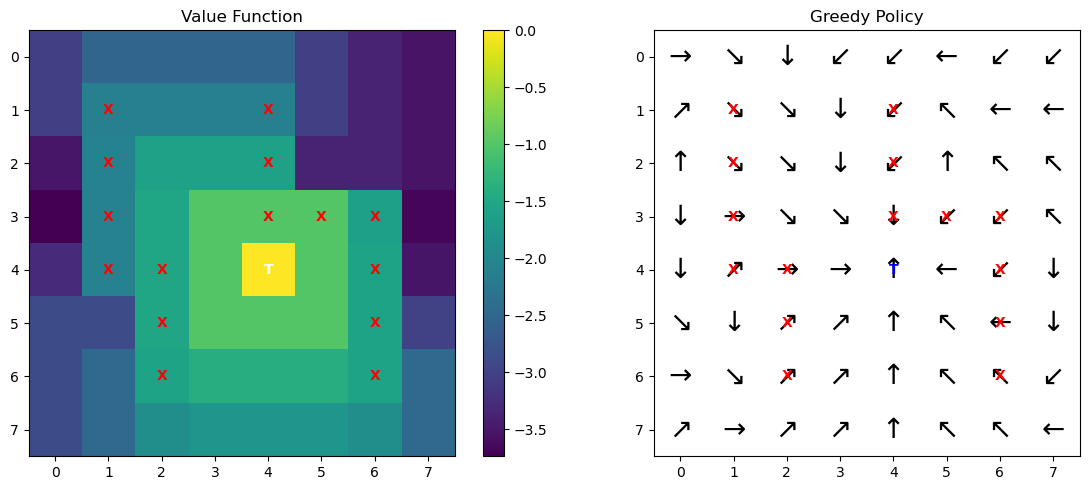

In [29]:
import matplotlib.pyplot as plt

def plot_gridworld_value_policy(V: np.ndarray, pi: np.ndarray):
    """Display heatmaps of the value function and the greedy action."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Value function
    v_grid = V.reshape(8, 8)
    im0 = axes[0].imshow(v_grid, cmap='viridis', origin='upper')
    axes[0].set_title("Value Function")
    plt.colorbar(im0, ax=axes[0])
    # Mark blocked cells and terminal
    for (r,c) in env.env.inv_state:
        axes[0].text(c, r, 'X', ha='center', va='center', color='red', fontweight='bold')
    axes[0].text(4, 4, 'T', ha='center', va='center', color='white', fontweight='bold')
    
    # Policy (best action)
    action_grid = np.argmax(pi, axis=1).reshape(8, 8)
    # Map action numbers to arrows
    action_symbols = ['↑', '↗', '→', '↘', '↓', '↙', '←', '↖', '·']
    im1 = axes[1].imshow(np.zeros((8,8)), cmap='Greys', vmin=0, vmax=1, alpha=0)
    for i in range(8):
        for j in range(8):
            a = action_grid[i, j]
            axes[1].text(j, i, action_symbols[a], ha='center', va='center', fontsize=20)
    axes[1].set_title("Greedy Policy")
    # Mark blocked and terminal
    for (r,c) in env.env.inv_state:
        axes[1].text(c, r, 'X', ha='center', va='center', color='red', fontweight='bold')
    axes[1].text(4, 4, 'T', ha='center', va='center', color='blue', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot the optimal policy from value iteration
plot_gridworld_value_policy(V_vi, pi_vi)

#### 6. Summary

- We have successfully implemented **policy evaluation**, **policy iteration**, and **value iteration** for the 8×8 GridWorld environment.  
- The optimal policy navigates the agent to the terminal `[4,4]` while avoiding blocked cells and the large penalty for invalid moves.